n	время(мс)
10	0.034
50	0.125
100	0.300
200	0.978
300	1.926
400	16.073
500	14.446

замеры для n=100 (30 раз):
1: 0.287
2: 0.257
3: 0.256
4: 0.265
5: 0.284
6: 0.265
7: 0.262
8: 0.226
9: 1.846
10: 0.277
11: 0.270
12: 0.314
13: 0.296
14: 0.282
15: 0.266
16: 0.284
17: 0.269
18: 0.288
19: 0.300
20: 0.306
21: 0.244
22: 0.262
23: 0.251
24: 0.275
25: 0.297
26: 0.309
27: 0.322
28: 0.237
29: 0.263
30: 0.256

среднее = 0.327 мс
ско = 0.283 мс
мин = 0.226 мс
макс = 1.846 мс


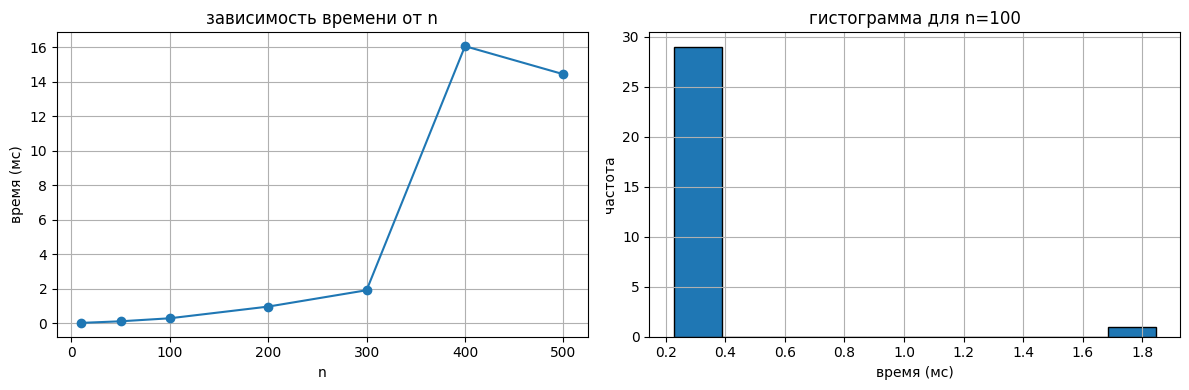

In [11]:
import random
import time
import matplotlib.pyplot as plt

class Interval:
    def __init__(self, start, finish, weight):
        self.start = start
        self.finish = finish
        self.weight = weight

def solve(intervals):
    intervals.sort(key=lambda x: x.finish)
    n = len(intervals)
    p = [-1] * n
    for i in range(n):
        for j in range(i-1, -1, -1):
            if intervals[j].finish <= intervals[i].start:
                p[i] = j
                break
    dp = [0] * n
    for i in range(n):
        take = intervals[i].weight
        if p[i] != -1:
            take += dp[p[i]]
        not_take = dp[i-1] if i > 0 else 0
        dp[i] = max(take, not_take)
    return dp[n-1]

def gen(n):
    arr = []
    for i in range(n):
        s = random.randint(1, 100)
        f = s + random.randint(10, 50)
        w = random.randint(1, 20)
        arr.append(Interval(s, f, w))
    return arr

# 1. замеры для разных n
print("n\tвремя(мс)")
sizes = [10, 50, 100, 200, 300, 400, 500]
times_n = []
for n in sizes:
    data = gen(n)
    t1 = time.time()
    solve(data)
    t2 = time.time()
    t = (t2 - t1) * 1000
    times_n.append(t)
    print(f"{n}\t{t:.3f}")

# 2. много замеров для n=100
print("\nзамеры для n=100 (30 раз):")
times_100 = []
for i in range(30):
    data = gen(100)
    t1 = time.time()
    solve(data)
    t2 = time.time()
    t = (t2 - t1) * 1000
    times_100.append(t)
    print(f"{i+1}: {t:.3f}")

# статистика
avg = sum(times_100) / len(times_100)
std = (sum((x - avg)**2 for x in times_100) / len(times_100))**0.5
print(f"\nсреднее = {avg:.3f} мс")
print(f"ско = {std:.3f} мс")
print(f"мин = {min(times_100):.3f} мс")
print(f"макс = {max(times_100):.3f} мс")

# график
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(sizes, times_n, 'o-')
plt.xlabel('n')
plt.ylabel('время (мс)')
plt.title('зависимость времени от n')
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(times_100, bins=10, edgecolor='black')
plt.xlabel('время (мс)')
plt.ylabel('частота')
plt.title(f'гистограмма для n=100')
plt.grid(True)

plt.tight_layout()
plt.savefig('result.png')
plt.show()